## Prompt chaining

**Prompt chaining** is a technique in natural language processing where **multiple prompts are sequenced together to guide a model through a complex task or reasoning process**. Instead of relying on a single prompt to achieve the desired outcome, prompt chaining breaks the task into smaller, managable steps, with each step building on the previous one. This approach can improve accuracy, coherence, and contol when working with LLMs. **Langgraph** is a framework designed to facilitate structured interactions with LLMs, making it excelent tool for implementing **prompt chaining**. It allows you to define a graph of nodes (representing individual prompts of tasks) and edges (representing the flow of inforation between them). This structure emables dynamic, multi-step conversations of workflows, where the output of one node can feed into the input of the next.



### How Prompt chaining works?

1. **Define the task**: Start by breaking down the problem into staller sub-tasks. For example, if you want to generate a detailed report, you might split it into steps like **"gather data"**, **"analyze data"** and **"write summary"**
2. **Create nodes**: Each sub-task becomes a node in the Langgraph structure. A Node could be a prompt that instructs the model to perform a specific action, such as **"List key facts about X"** or **"Summarize the following text"**.
3. **Establis edges**: Edges defines the sequence and dependecies between nodes. For instance the output of the "gather data" node flows into the "analyze data" node, ensuring the model has the nescessary context to proceed. 
4. **Execute the graph**: Langgraph processes the nodes in order, passing information through the nodes. The model generates responses step-by-step, refining the output as it progresses through the chain. 
5. **Iterate if needed**: Langgraph supports conditional logic and loops, so you can revisit earlier nodes or adjust the flow based on intermediate results.

In [ ]:
import os
from dotenv import load_dotenv

ENV_PATH = '../.env'
assert os.path.exists(ENV_PATH)

load_dotenv('../.env')

GROQ_API_KEY = os.environ['GROQ_API_KEY']
assert GROQ_API_KEY
print(f'----> GROQ_API_KEY: {GROQ_API_KEY[:3]}***{GROQ_API_KEY[-3:]}')


LANGCHAIN_API_KEY = os.environ['LANGCHAIN_API_KEY']
assert LANGCHAIN_API_KEY
print(f'----> LANGCHAIN_API_KEY: {LANGCHAIN_API_KEY[:3]}***{LANGCHAIN_API_KEY[-3:]}')

# Required by LangChain 
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
LANGCHAIN_PROJECT = 'Promp chaining example'
os.environ['LANGCHAIN_PROJECT'] = LANGCHAIN_PROJECT
print(f'---->LANGCHAIN_PROJECT: {LANGCHAIN_PROJECT}')

----> GROQ_API_KEY: gsk***qNU
----> LANGCHAIN_API_KEY: lsv***43b
LANGCHAIN_PROJECT: Promp chaining example


In [13]:
from langchain_groq import ChatGroq

#LLM temperature is a parameter that controls the randomness and creativity of a large language model's output by adjusting the probability distribution of next-word predictions. Lower temperatures (e.g., <0.5) make the output more predictable and deterministic, favoring more common, "safer" words, which is good for factual accuracy. Higher temperatures (e.g., >0.8) increase randomness, leading to more varied, creative, and surprising outputs, ideal for tasks like brainstorming or storytelling. 
llm = ChatGroq(model='qwen/qwen3-32b', temperature=0, reasoning_format='hidden')
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x10fee3ed0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x118010910>, model_name='qwen/qwen3-32b', temperature=1e-08, reasoning_format='hidden', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [14]:
from langchain_core.messages import HumanMessage
response = llm.invoke(input=[HumanMessage(content='I am Dimo and I like apples')])
response.pretty_print()

================================== Ai Message ==================================

Hello Dimo! 🍎 It's great to meet you. I love that you enjoy apples - they're such versatile and delicious fruits! Do you have a favorite type of apple or a special way you like to enjoy them? I'd love to hear more about your apple adventures!


#### Create Langgraph graph

In [15]:
from typing import Literal
from IPython.display import display, Image

from typing_extensions import Annotated, TypedDict
from langgraph.graph.message import add_messages, AnyMessage
from langgraph.graph import StateGraph, START, END
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

class State(TypedDict):
    topic: str
    story: str 
    improved_story: str
    final_story: str

def generate_story(state: State) -> State:
    msg = llm.invoke(input=[HumanMessage(content=f'Write a sentence story premise about {state["topic"]}')])
    return {"story": msg.content}

def check_conflict(state: State) -> Literal['Fail', 'Pass']:
    print(f'Checking confict for story: {state["story"]}')
    if '?' in state['story'] or '!' in state['story']:
        return 'Fail'
    return 'Pass'

def improved_story(state: State) -> State:
    msg = llm.invoke(input=[HumanMessage(content=f'Enhance this story premise with vivid details: \n {state["story"]}')])
    return {"improved_story": msg.content}

def polish_story(state: State) -> State:
    msg = llm.invoke(input=[HumanMessage(content=f'Add an unexpected twist to this story premise: {state["improved_story"]}')])
    return {"final_story": msg.content}

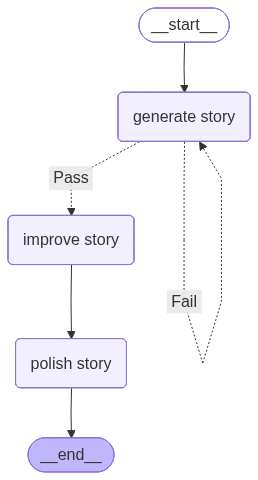

In [16]:
graph_buider = StateGraph(State)

# Add nodes
graph_buider.add_node('generate story', generate_story)
graph_buider.add_node('improve story', improved_story)
graph_buider.add_node('polish story', polish_story)

# Define edges
graph_buider.add_edge(START, 'generate story')
graph_buider.add_conditional_edges('generate story', check_conflict, {
    'Fail': 'generate story',
    'Pass': 'improve story'
})
graph_buider.add_edge('improve story', 'polish story')
graph_buider.add_edge('polish story', END)

graph = graph_buider.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
input_state: State = {'topic': 'Football'}
output_state = graph.invoke(input=input_state)
output_state

Checking confict for story: In a dusty, remote village where football is played on a makeshift field between two ancient banyan trees, a determined young girl rallies her skeptical peers to challenge the reigning national champions, using her grandfather’s weathered playbook and an unorthodox strategy born from years of mending broken equipment, betting their town’s dwindling hope on a single match under the harvest moon.


{'topic': 'Football',
 'story': 'In a dusty, remote village where football is played on a makeshift field between two ancient banyan trees, a determined young girl rallies her skeptical peers to challenge the reigning national champions, using her grandfather’s weathered playbook and an unorthodox strategy born from years of mending broken equipment, betting their town’s dwindling hope on a single match under the harvest moon.',
 'improved_story': '**Enhanced Story Premise:**  \n\nIn the sun-scorched village of **Dhruvanchal**, where the earth cracks like aged leather and the wind carries the scent of scorched millet, a makeshift football field stretches between two **century-old banyan trees**. Their gnarled roots twist like ancient serpents, and their canopies—swaying in the monsoon’s final, lazy breaths—cast the only shade for miles. The goalposts are rusted bicycle frames, lashed together with hope, and the ball? A **patchwork of tire rubber, leather scraps, and frayed jute**—a tes